# Import Required Libraries and Filter Modules

In [32]:
import pandas as pd
import numpy as np
from lkf import LinearKalmanFilter
from lkf_with_SVD import LinearKalmanFilter_with_SVD
from sqrt_kf import SqrtKalmanFilter
from adaptive_kalman_filter_svd import AdaptiveSVDKalmanFilter
from adaptive_kalman_filter_sqrt import AdaptiveSqrtKalmanFilter
from adaptive_kalman_filter import AdaptiveKalmanFilter


# Load Sample DataFrame

In [33]:
# Load the dataframe from CSV
df = pd.read_csv('datasets/differenced/server_2026_03_12_gaps.csv')
print(df.head())

    timestamp  CSAC1 - AHM1  CS1 - AHM1  CSAC2 - AHM1  CSAC3 - AHM1  \
0  1773349375     -3.456815    0.000278     -4.890209     -4.889675   
1  1773349376     -3.456815    0.000278     -4.890209     -4.889675   
2  1773349377     -3.456815    0.000278     -4.890209     -4.889675   
3  1773349378     -3.456815    0.000278     -4.890209     -4.889675   
4  1773349379     -3.456815    0.000278     -4.890209     -4.889675   

   AHM2 - AHM1  
0     0.000278  
1     0.000278  
2     0.000278  
3     0.000278  
4     0.000278  


# Define Filter Selection Logic

In [34]:
# Define which filters to use and which columns to filter
use_lkf = True
use_svd_lkf = False
use_svd_lkf_adaptive = False
use_sqrt_kf = False
use_sqrt_kf_adaptive = True
use_lkf_adaptive = False
columns_to_filter = ['AHM2 - AHM1', 'CS1 - AHM1']# 'CSAC1 - AHM1', 'CSAC2 - AHM1', 'CSAC3 - AHM1']  # List of column names to apply filters to

# Ensure columns exist in df
columns_to_filter = [col for col in columns_to_filter if col in df.columns]

# Define Model Type for Filtering

In [35]:
# Define the selected components: list of 'phase', 'frequency', 'drift'
selected_components = ['phase', 'frequency']  # Change this list to select which states to include, e.g., ['phase', 'frequency']
dt = 1.0  # Time step



if not selected_components:
    raise ValueError("selected_components cannot be empty")

# Full model matrices
full_components = ['phase', 'frequency', 'drift']
F_full = np.array([[1, dt, dt**2/2], [0, 1, dt], [0, 0, 1]])
H_full = np.array([1, 0, 0])  # measures phase

# Get indices of selected components
indices = [full_components.index(c) for c in selected_components]
n_state_per_col = len(selected_components)

# Subset matrices
F_single = F_full[np.ix_(indices, indices)]
H_single = H_full[indices]

n_cols = len(columns_to_filter)
n_state = n_cols * n_state_per_col

# Build block diagonal F and H
F = np.kron(np.eye(n_cols), F_single)
H = np.kron(np.eye(n_cols), H_single.reshape(1, -1))

# Tie R directly to your observed data statistics
phase_variances = []
for col in columns_to_filter:
    phase_variances.append(np.var([df[col].values[i] for i in range(len(df)) if not np.isnan(df[col].values[i])]))

# R = np.diag([phase_variances[i] for i in range(len(phase_variances))])  # shape (n_cols, n_cols)

# Ill-conditioning parameter
delta = 5
# # TRY POORLY TUNE R WITH SMALL MAGNITUDE - near-perfect sensor
R_scale = delta**2
R = np.eye(n_cols) * delta**2


# Then set Q phase slightly smaller than R 
# so the filter trusts measurements but isn't jumpy
process_noise_variances = []
for i in range(len(phase_variances)):
    process_noise_variances.append({
        'phase': phase_variances[i] * 1e-1,
        'frequency': phase_variances[i] * 1e-2,
        'drift': phase_variances[i] * 1e-3,
    })
Q = np.diag([process_noise_variances[i][c] for i in range(len(process_noise_variances)) for c in selected_components])


# SET NAIVE Q
# Q = np.eye(n_state) * 1

Q_stressed_values = [1e-24, 1e-26, 1e-28]  # Example values for stressed Q
Q_stressed = np.diag(Q_stressed_values[:len(selected_components)] * n_cols)
R_stressed  = 1e-16 * np.eye(n_cols)

print("State transition matrix F:")
print(F)
print("\nMeasurement matrix H:")
print(H)
print("\nProcess noise covariance Q:")
print(Q)
print("\nMeasurement noise covariance R:")
print(R)

# Initial state: assume initial phase is the first data point, others 0
x0 = np.zeros(n_state)
for i, col in enumerate(columns_to_filter):
    if 'phase' in selected_components:
        phase_idx = selected_components.index('phase')
        x0[i * n_state_per_col + phase_idx] = df[col].iloc[0]
# # P0_blocks = [1e-8,  1e-10, 1e-12]
# P0_blocks = [1e-4, 1e-12, 1e-20]
# P0 = np.kron(np.eye(n_cols), np.diag(P0_blocks[:n_state_per_col]))
print(f"Inital stat x0:\n {x0}")
#Naive P0
P0 = np.eye(n_state)

State transition matrix F:
[[1. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 1.]
 [0. 0. 0. 1.]]

Measurement matrix H:
[[1. 0. 0. 0.]
 [0. 0. 1. 0.]]

Process noise covariance Q:
[[5.97620091e-18 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 5.97620091e-19 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 2.96184232e-20 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 2.96184232e-21]]

Measurement noise covariance R:
[[25.  0.]
 [ 0. 25.]]
Inital stat x0:
 [0.00027843 0.         0.00027839 0.        ]


# Apply lkf Filter to Selected Columns

In [36]:
if use_lkf and n_cols > 0:
    kf = LinearKalmanFilter()
    
    kf.set_matrices(F, H, R, Q)
    kf.set_initial_state(x0, P0)

    def is_pos_def(x):
        try:
            np.linalg.cholesky(x)
            return True
        except np.linalg.LinAlgError:
            return False

    filtered = {f"{col}_{comp}": [] for col in columns_to_filter for comp in selected_components}
    residuals_lkf = []
    for i in range(len(df)):
        row = df[columns_to_filter].iloc[i]
        kf.predict()
        if row.isna().any():
            kf.skip_update()
            residuals_lkf.append(np.full(n_cols, np.nan))
        else:
            z = row.values
            kf.update(z)
            residuals_lkf.append(kf.get_last_residual().copy())

        state = kf.get_updated_state()
        for j, col in enumerate(columns_to_filter):
            for k, comp in enumerate(selected_components):
                filtered[f"{col}_{comp}"].append(state[j * n_state_per_col + k])
    
    for key in filtered:
        df[f"{key}_lkf"] = filtered[key]

# Apply sqrt_kalman_filter

In [37]:
if use_sqrt_kf and n_cols > 0:
    sqrt_kf = SqrtKalmanFilter()
    
    sqrt_kf.set_matrices(F, H, R, Q)
    sqrt_kf.set_initial_state(x0, P0)

    filtered = {f"{col}_{comp}": [] for col in columns_to_filter for comp in selected_components}
    residuals_sqrt_kf = []
    for i in range(len(df)):
        row = df[columns_to_filter].iloc[i]
        sqrt_kf.predict()
        if row.isna().any():
            sqrt_kf.skip_update()
            residuals_sqrt_kf.append(np.full(n_cols, np.nan))
        else:
            z = row.values
            sqrt_kf.update(z)
            residuals_sqrt_kf.append(sqrt_kf.get_last_residual().copy())

        state = sqrt_kf.get_updated_state()
        for j, col in enumerate(columns_to_filter):
            for k, comp in enumerate(selected_components):
                filtered[f"{col}_{comp}"].append(state[j * n_state_per_col + k])
    
    for key in filtered:
        df[f"{key}_sqrt_kf"] = filtered[key]

# Apply lkf_with_SVD Filter to Selected Columns

In [38]:
if use_svd_lkf and n_cols > 0:
    kf_svd = LinearKalmanFilter_with_SVD()
    
    kf_svd.set_matrices(F, H, R, Q)
    kf_svd.set_initial_state(x0, P0)
    kf_svd.initialize()
    
    filtered = {f"{col}_{comp}": [] for col in columns_to_filter for comp in selected_components}
    residuals_svd_lkf = []
    for i in range(len(df)):
        row = df[columns_to_filter].iloc[i]
        if row.isna().any():
            kf_svd.skip_update()
            residuals_svd_lkf.append(np.full(n_cols, np.nan))
        else:
            z = row.values
            kf_svd.update(z)
            residuals_svd_lkf.append(kf_svd.get_last_residual().copy())

        state = kf_svd.get_updated_state()
        for j, col in enumerate(columns_to_filter):
            for k, comp in enumerate(selected_components):
                filtered[f"{col}_{comp}"].append(state[j * n_state_per_col + k])
        kf_svd.predict()

    for key in filtered:
        df[f"{key}_svd_lkf"] = filtered[key]

# Apply adaptive_kalman_filter (linear)

In [39]:
if use_lkf_adaptive and n_cols > 0:
    lkf_adaptive = AdaptiveKalmanFilter()
    
    lkf_adaptive.set_matrices(F, H, R, Q)
    lkf_adaptive.set_initial_state(x0, P0)
    lkf_adaptive.set_adaptive_params(20)

    filtered = {f"{col}_{comp}": [] for col in columns_to_filter for comp in selected_components}
    residuals_lkf_adaptive = []
    for i in range(len(df)):
        lkf_adaptive.predict()
        row = df[columns_to_filter].iloc[i]
        if row.isna().any():
            lkf_adaptive.skip_update()
            residuals_lkf_adaptive.append(np.full(n_cols, np.nan))
        else:
            z = row.values
            lkf_adaptive.push_signal_sample(z)
            lkf_adaptive.update(z)
            residuals_lkf_adaptive.append(lkf_adaptive.get_last_residual().copy())

        state = lkf_adaptive.get_updated_state()
        for j, col in enumerate(columns_to_filter):
            for k, comp in enumerate(selected_components):
                filtered[f"{col}_{comp}"].append(state[j * n_state_per_col + k])
    
    for key in filtered:
        df[f"{key}_lkf_adaptive"] = filtered[key]

# Apply adaptive_kalman_filter_svd

In [40]:
if use_svd_lkf_adaptive and n_cols > 0:
    kf_adaptive_svd = AdaptiveSVDKalmanFilter()
    
    kf_adaptive_svd.set_matrices(F, H, R, Q)
    kf_adaptive_svd.set_initial_state(x0, P0)
    kf_adaptive_svd.set_adaptive_params(20)
    kf_adaptive_svd.initialize()

    filtered = {f"{col}_{comp}": [] for col in columns_to_filter for comp in selected_components}
    residuals_svd_lkf_adaptive = []
    for i in range(len(df)):
        row = df[columns_to_filter].iloc[i]
        if row.isna().any():
            kf_adaptive_svd.skip_update()
            residuals_svd_lkf_adaptive.append(np.full(n_cols, np.nan))
        else:
            z = row.values
            kf_adaptive_svd.push_signal_sample(z)
            kf_adaptive_svd.update(z)
            residuals_svd_lkf_adaptive.append(kf_adaptive_svd.get_last_residual().copy())

        state = kf_adaptive_svd.get_updated_state()
        for j, col in enumerate(columns_to_filter):
            for k, comp in enumerate(selected_components):
                filtered[f"{col}_{comp}"].append(state[j * n_state_per_col + k])
        kf_adaptive_svd.predict()
    
    for key in filtered:
        df[f"{key}_lkf_adaptive_svd"] = filtered[key]

# Apply Adaptive Sqrt KF

In [41]:
if use_sqrt_kf_adaptive and n_cols > 0:
    kf_adaptive_sqrt = AdaptiveSqrtKalmanFilter()
    
    kf_adaptive_sqrt.set_matrices(F, H, R, Q)
    kf_adaptive_sqrt.set_initial_state(x0, P0)
    kf_adaptive_sqrt.set_adaptive_params(20)

    filtered = {f"{col}_{comp}": [] for col in columns_to_filter for comp in selected_components}
    residuals_sqrt_kf_adaptive = []
    for i in range(len(df)):
        

        kf_adaptive_sqrt.predict()
        row = df[columns_to_filter].iloc[i]
        if row.isna().any():
            kf_adaptive_sqrt.skip_update()
            residuals_sqrt_kf_adaptive.append(np.full(n_cols, np.nan))
        else:
            z = row.values
            kf_adaptive_sqrt.push_signal_sample(z)
            kf_adaptive_sqrt.update(z)
            residuals_sqrt_kf_adaptive.append(kf_adaptive_sqrt.get_last_residual().copy())
            

        state = kf_adaptive_sqrt.get_updated_state()
        for j, col in enumerate(columns_to_filter):
            for k, comp in enumerate(selected_components):
                filtered[f"{col}_{comp}"].append(state[j * n_state_per_col + k])
    
    for key in filtered:
        df[f"{key}_sqrt_kf_adaptive"] = filtered[key]

# Plot Filter Residuals (Innovation)

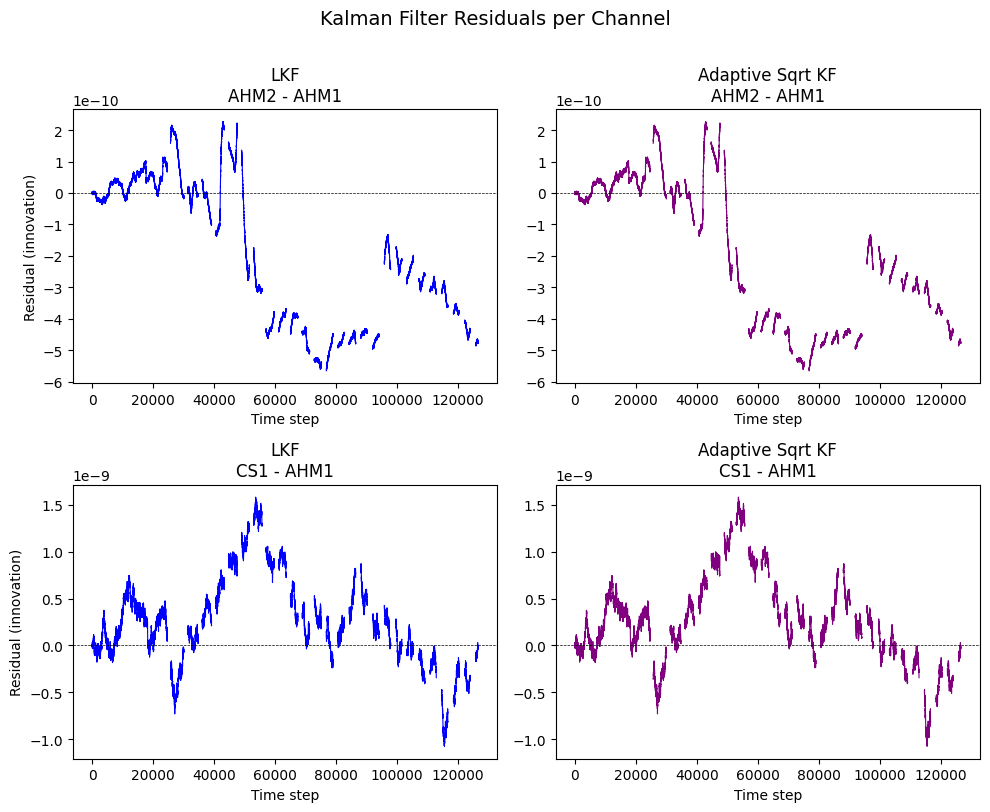

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# point_range = [0, 2000]
point_range = [0, len(df)]  # Plot the entire range

# Build a dict of (label, color, residuals_list) for enabled filters
active_residuals = []
if use_lkf and 'residuals_lkf' in dir():
    active_residuals.append(('LKF',               'blue',   residuals_lkf))
if use_sqrt_kf and 'residuals_sqrt_kf' in dir():
    active_residuals.append(('Sqrt KF',            'gold',   residuals_sqrt_kf))
if use_svd_lkf and 'residuals_svd_lkf' in dir():
    active_residuals.append(('SVD LKF',            'orange', residuals_svd_lkf))
if use_lkf_adaptive and 'residuals_lkf_adaptive' in dir():
    active_residuals.append(('Adaptive LKF',       'brown',  residuals_lkf_adaptive))
if use_svd_lkf_adaptive and 'residuals_svd_lkf_adaptive' in dir():
    active_residuals.append(('Adaptive SVD LKF',   'red',    residuals_svd_lkf_adaptive))
if use_sqrt_kf_adaptive and 'residuals_sqrt_kf_adaptive' in dir():
    active_residuals.append(('Adaptive Sqrt KF',   'purple', residuals_sqrt_kf_adaptive))

fig, axes = plt.subplots(n_cols, len(active_residuals), figsize=(5 * len(active_residuals), 4 * n_cols), squeeze=False)

for j, col in enumerate(columns_to_filter):
    for k, (label, color, res_list) in enumerate(active_residuals):
        ax = axes[j][k]
        # Extract residual for this column across all timesteps
        res_col = np.array([r[j] if r is not None else np.nan for r in res_list])
        ax.plot(res_col[point_range[0]:point_range[1]], color=color, linewidth=0.8)
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.set_title(f'{label}\n{col}')
        ax.set_xlabel('Time step')
        if k == 0:
            ax.set_ylabel('Residual (innovation)')

plt.suptitle('Kalman Filter Residuals per Channel', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Combine Results and Display Output

In [43]:
# Display the resulting DataFrame
print(df.head())

# Optionally, save the filtered data
# df.to_csv('filtered_data.csv', index=False)

    timestamp  CSAC1 - AHM1  CS1 - AHM1  CSAC2 - AHM1  CSAC3 - AHM1  \
0  1773349375     -3.456815    0.000278     -4.890209     -4.889675   
1  1773349376     -3.456815    0.000278     -4.890209     -4.889675   
2  1773349377     -3.456815    0.000278     -4.890209     -4.889675   
3  1773349378     -3.456815    0.000278     -4.890209     -4.889675   
4  1773349379     -3.456815    0.000278     -4.890209     -4.889675   

   AHM2 - AHM1  AHM2 - AHM1_phase_lkf  AHM2 - AHM1_frequency_lkf  \
0     0.000278               0.000278               0.000000e+00   
1     0.000278               0.000278              -2.528479e-13   
2     0.000278               0.000278              -4.009570e-13   
3     0.000278               0.000278              -3.682643e-13   
4     0.000278               0.000278              -3.024428e-13   

   CS1 - AHM1_phase_lkf  CS1 - AHM1_frequency_lkf  \
0              0.000278              0.000000e+00   
1              0.000278             -3.309270e-13   
2    

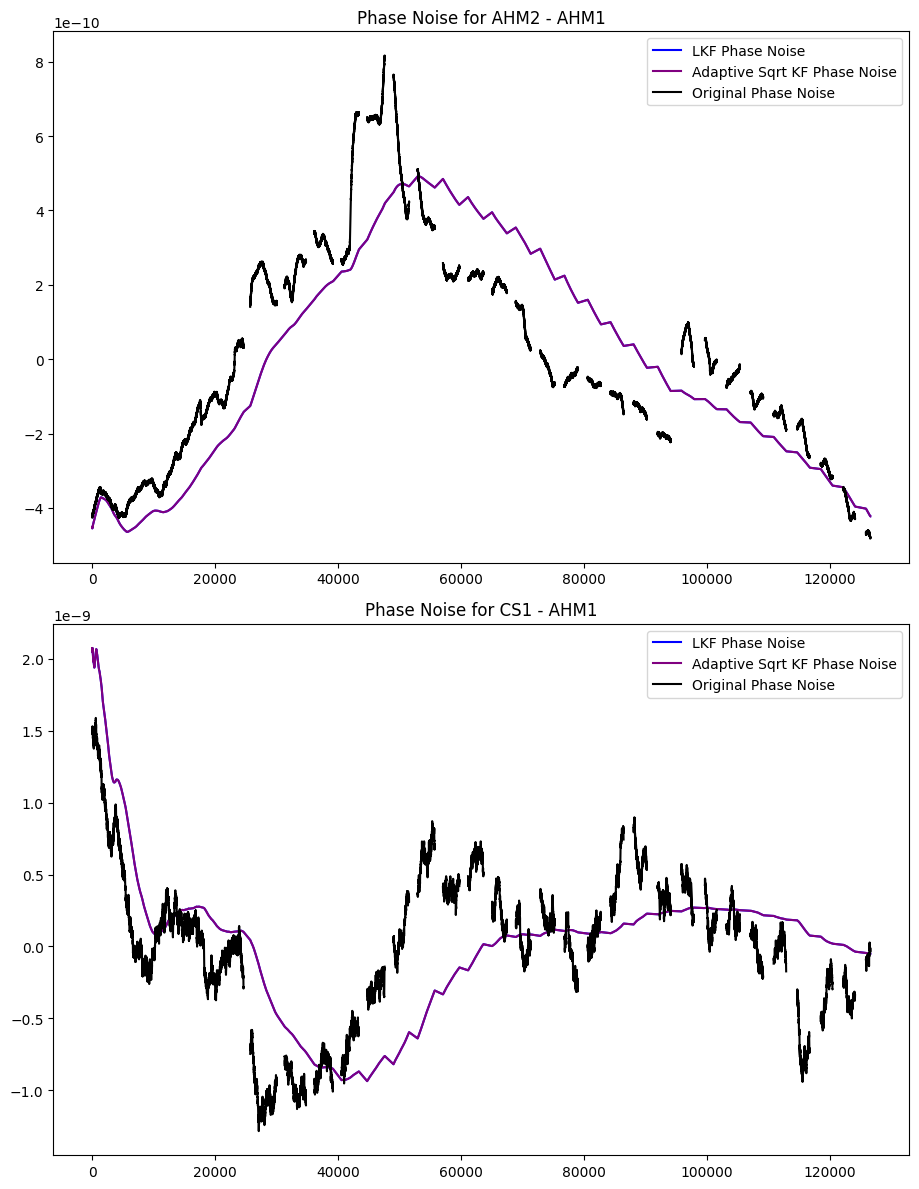

In [44]:
import matplotlib.pyplot as plt

# Fit and remove linear trend from phase to visualize noise
def detrend_phase(signal):
    x = np.arange(len(signal))
    # Remove NaN before fitting trend
    mask = ~np.isnan(signal)
    coeffs = np.polyfit(x[mask], signal[mask], 1)
    trend = np.polyval(coeffs, x)
    return signal - trend  # NaN values stay NaN but trend is correct everywhere


# # point_range = [0, 2000]
# point_range = [0, len(df)]  # Plot the entire range

plt.figure(figsize=(18, 12))
for i, col in enumerate(columns_to_filter):
    plt.subplot(n_cols, 2, i*2 + 1)
    
    # Detrend the original phase
    original_phase_noise = detrend_phase(df[col].values)
    
    if use_svd_lkf:
        svd_phase_noise = detrend_phase(df[f"{col}_phase_svd_lkf"].values)
        plt.plot(svd_phase_noise[point_range[0]:point_range[1]], label='SVD LKF Phase Noise', color = 'orange')
    if use_lkf:
        lkf_phase_noise = detrend_phase(df[f"{col}_phase_lkf"].values)
        plt.plot(lkf_phase_noise[point_range[0]:point_range[1]], label='LKF Phase Noise', color = 'blue')
    if use_sqrt_kf:
        sqrt_phase_noise = detrend_phase(df[f"{col}_phase_sqrt_kf"].values)
        plt.plot(sqrt_phase_noise[point_range[0]:point_range[1]], label = 'Sqrt KF Phase Noise', color = 'yellow')
    
    if use_svd_lkf_adaptive:
        adaptive_phase_noise = detrend_phase(df[f"{col}_phase_lkf_adaptive_svd"].values)
        plt.plot(adaptive_phase_noise[point_range[0]:point_range[1]], label = 'SVD Adaptive LKF Phase Noise', color = 'red')

    if use_sqrt_kf_adaptive:
        adaptive_sqrt_phase_noise = detrend_phase(df[f"{col}_phase_sqrt_kf_adaptive"].values)
        plt.plot(adaptive_sqrt_phase_noise[point_range[0]:point_range[1]], label = 'Adaptive Sqrt KF Phase Noise', color = 'purple')
        
    if use_lkf_adaptive:
        adaptive_lkf_phase_noise = detrend_phase(df[f"{col}_phase_lkf_adaptive"].values)
        plt.plot(adaptive_lkf_phase_noise[point_range[0]:point_range[1]], label = 'Adaptive LKF Phase Noise', color = 'brown')
        

     
    plt.plot(original_phase_noise[point_range[0]:point_range[1]], label='Original Phase Noise', color = 'black')
    
    plt.title(f"Phase Noise for {col}")
    plt.legend()

    


plt.tight_layout()
plt.show()


-1.9744122491000197e-13
-4.110149355753999e-14


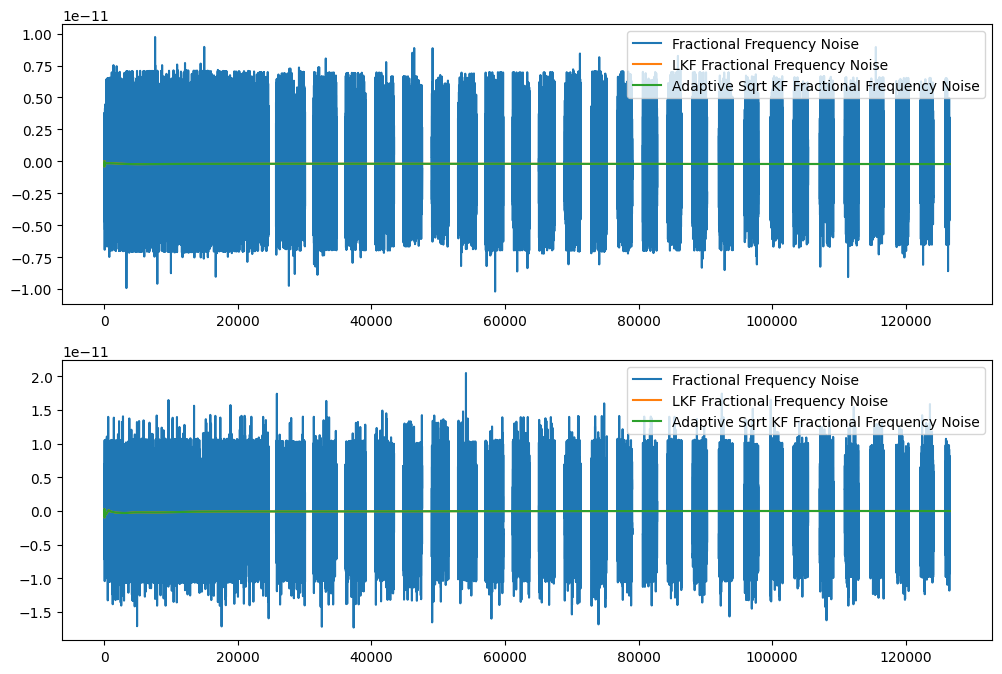

In [45]:
# plot fractional frequency noise (derivative of phase)

fractional_frequency_noise = np.diff(df[columns_to_filter].values, axis=0) / dt

plt.figure(figsize=(12, 8))
for i, col in enumerate(columns_to_filter):
    plt.subplot(n_cols, 1, i + 1)
    plt.plot(fractional_frequency_noise[point_range[0]:point_range[1] - 1, i], label='Fractional Frequency Noise')
    
    if use_svd_lkf:
        plt.plot(df[f'{col}_frequency_svd_lkf'].values[point_range[0]:point_range[1]-1], label='SVD LKF Fractional Frequency Noise')
    if use_lkf:
        plt.plot(df[f'{col}_frequency_lkf'].values[point_range[0]:point_range[1]-1], label='LKF Fractional Frequency Noise')
    
    if use_svd_lkf_adaptive:
        plt.plot(df[f'{col}_frequency_lkf_adaptive'].values[point_range[0]:point_range[1]-1], label='Adaptive SVD LKF Fractional Frequency Noise')
    
    if use_sqrt_kf:
        plt.plot(df[f'{col}_frequency_sqrt_kf'].values[point_range[0]:point_range[1]-1], label='Sqrt KF Fractional Frequency Noise')
    
    if use_sqrt_kf_adaptive:
        plt.plot(df[f'{col}_frequency_sqrt_kf_adaptive'].values[point_range[0]:point_range[1]-1], label='Adaptive Sqrt KF Fractional Frequency Noise')
    
    if use_lkf_adaptive:
        plt.plot(df[f'{col}_frequency_lkf_adaptive'].values[point_range[0]:point_range[1]-1], label='Adaptive LKF Fractional Frequency Noise')
    
    plt.legend()      
    print(np.nanmean(df[f'{col}_frequency_sqrt_kf_adaptive'].values[point_range[0]:point_range[1]-1]))  